# Income & Spending Survey — Analysis

Loads the CSV exported by `export_to_csv.py` and produces the client-facing
visualizations for the healthcare product launch:

1. Ages with the highest income
2. Gender distribution across spending categories
3. Exported PNG charts, ready to drop into the client PowerPoint (see `generate_pptx.py`)


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CSV_PATH = "../data/survey_export.csv"
CHART_DIR = "../data/charts"

import os
os.makedirs(CHART_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df.head()


,age,gender,total_income,total_expenses,savings,expense_utilities,expense_entertainment,expense_school_fees,expense_shopping,expense_healthcare
0,30,male,10000.0,10000.0,0.0,1500.0,1000.0,4000.0,1500.0,2000.0
1,28,female,5000.0,5000.0,0.0,2000.0,1000.0,0.0,2000.0,0.0
2,25,female,2000.0,2000.0,0.0,500.0,500.0,0.0,1000.0,0.0
3,28,female,2000.0,2000.0,0.0,1000.0,0.0,0.0,1000.0,0.0
4,30,male,8000.0,8000.0,0.0,0.0,1500.0,0.0,4000.0,2500.0


## 1. Ages with the highest income

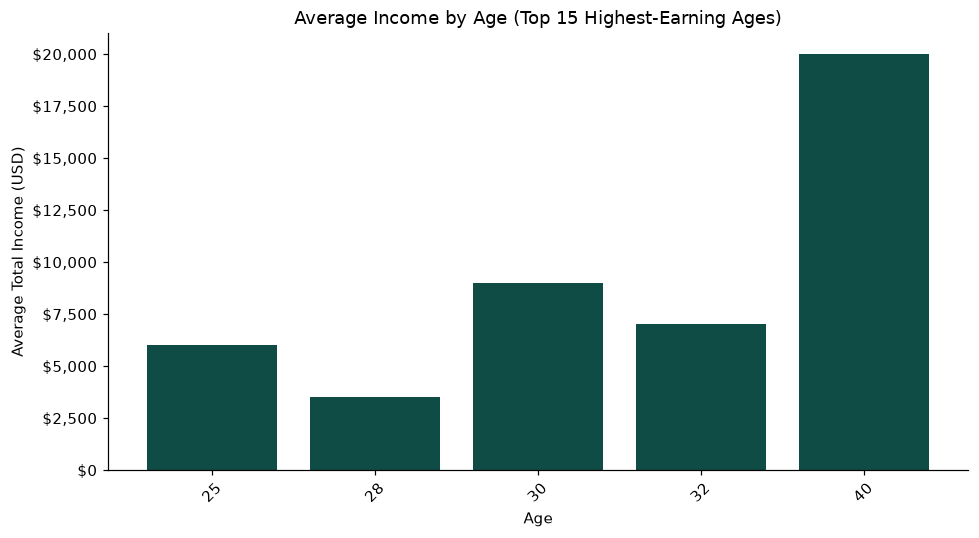

age
40    20000.0
30     9000.0
32     7000.0
25     6000.0
28     3500.0
Name: total_income, dtype: float64

In [12]:
# Average total income by age, sorted to surface the highest-earning ages
income_by_age = (
    df.groupby("age")["total_income"]
    .mean()
    .sort_values(ascending=False)
)

top_ages = income_by_age.head(15).sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(top_ages.index.astype(str), top_ages.values, color="#0f4c45")
ax.set_title("Average Income by Age (Top 15 Highest-Earning Ages)")
ax.set_xlabel("Age")
ax.set_ylabel("Average Total Income (USD)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/income_by_age.png", dpi=150)
plt.show()

income_by_age.head(10)


## 2. Gender distribution across spending categories

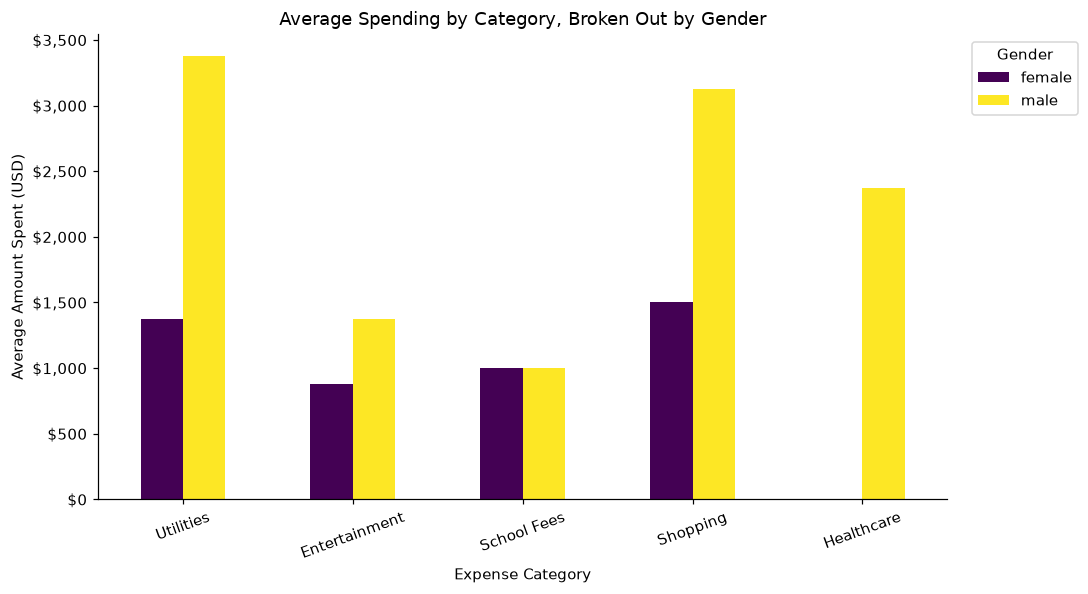

,Utilities,Entertainment,School Fees,Shopping,Healthcare
gender,,,,,
female,1375.0,875.0,1000.0,1500.0,0.0
male,3375.0,1375.0,1000.0,3125.0,2375.0


In [15]:
expense_cols = [c for c in df.columns if c.startswith("expense_")]

spend_by_gender = df.groupby("gender")[expense_cols].mean()
spend_by_gender.columns = [c.replace("expense_", "").replace("_", " ").title() for c in spend_by_gender.columns]

fig, ax = plt.subplots(figsize=(10, 5.5))
spend_by_gender.T.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Average Spending by Category, Broken Out by Gender")
ax.set_xlabel("Expense Category")
ax.set_ylabel("Average Amount Spent (USD)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/spending_by_gender.png", dpi=150)
plt.show()

spend_by_gender


## 3. Bonus: income vs. total expenses (savings rate)

Useful context for the healthcare product team: how much disposable
income different age groups have left after expenses.


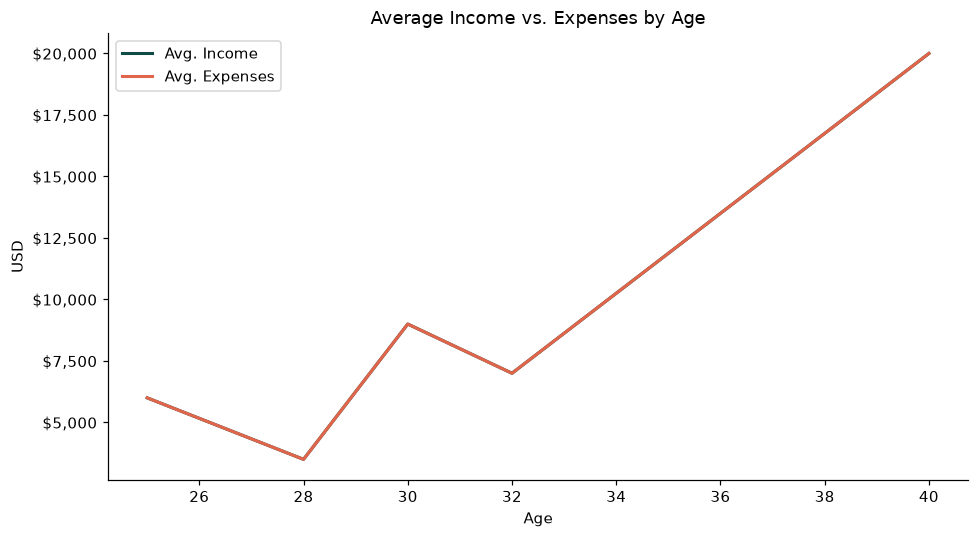

In [18]:
savings_by_age = df.groupby("age")[["total_income", "total_expenses"]].mean().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(savings_by_age.index, savings_by_age["total_income"], label="Avg. Income", color="#0f4c45", linewidth=2)
ax.plot(savings_by_age.index, savings_by_age["total_expenses"], label="Avg. Expenses", color="#e0654a", linewidth=2)
ax.fill_between(savings_by_age.index, savings_by_age["total_income"], savings_by_age["total_expenses"],
                 where=(savings_by_age["total_income"] >= savings_by_age["total_expenses"]),
                 color="#0f4c45", alpha=0.08)
ax.set_title("Average Income vs. Expenses by Age")
ax.set_xlabel("Age")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/income_vs_expenses_by_age.png", dpi=150)
plt.show()


## Export charts for the client PowerPoint

The three PNGs above are saved to `../data/charts/`. Run `generate_pptx.py`
from the project root to automatically assemble them into a client-ready
`.pptx` deck.
